# Solution 2: Logit Scoring Inference

Same training as Solution 1, but I changed the inference method. Instead of greedy decoding, I directly compared logits for each answer digit (0, 1, 2, ...) at the answer position and picked the highest. The idea was that raw logits might be more reliable than autoregressive generation.

It backfired. Score dropped from 0.78068 to 0.72635.

**Score: 0.72635**

## 0. Install Dependencies

In [2]:
!pip install -q "transformers==4.47.0"

!pip uninstall -y torchao 2>/dev/null

!pip install -q accelerate peft bitsandbytes datasets pillow tqdm pandas

import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print("✓ All good. If you just ran this for the first time, do Runtime → Restart session, then run all cells.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 53.6 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.5 MB/s eta 0:00:00
transformers: 4.47.0
peft: 0.18.1
✓ All good. If you just ran this for the first time, do Runtime → Restart session, then run all cells.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [5]:
import transformers
print(f"transformers: {transformers.__version__}")
assert transformers.__version__ >= "4.45.0", f"Too old: {transformers.__version__} — restart runtime after running cell 0"

import os
import json
import re
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, TaskType

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

DATA_DIR = "/content/drive/MyDrive/pixels-to-predictions"
IMG_BASE = os.path.join(DATA_DIR, "images")

OUTPUT_DIR = "/content/smolvlm-lora-finetuned"
CKPT_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LEARNING_RATE = 1e-4
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
NUM_EPOCHS = 5
WARMUP_RATIO = 0.1
MAX_SEQ_LEN = 1024
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

transformers: 4.47.0
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Load Data

In [6]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

sample_path = os.path.join(IMG_BASE, train_df['image_path'].iloc[0])
assert os.path.exists(sample_path), f"Image not found: {sample_path}. Check IMG_BASE path."
print(f"✓ Images accessible at {IMG_BASE}")

Train: 3109 | Val: 1048 | Test: 1008
✓ Images accessible at /content/drive/MyDrive/pixels-to-predictions/images


## 3. Load Model & Processor

In [7]:
processor = AutoProcessor.from_pretrained(MODEL_ID)

processor.image_processor.size = {"longest_edge": 512}

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

print("Model type:", type(model).__name__)
print(f"Image processor size: {processor.image_processor.size}")
print("\nModel modules (first 2 levels):")
for name, _ in model.named_modules():
    parts = name.split(".")
    if len(parts) <= 3:
        print(f"  {name}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model type: Idefics3ForConditionalGeneration
Image processor size: {'longest_edge': 512}

Model modules (first 2 levels):
  
  model
  model.vision_model
  model.vision_model.embeddings
  model.vision_model.encoder
  model.vision_model.post_layernorm
  model.connector
  model.connector.modality_projection
  model.text_model
  model.text_model.embed_tokens
  model.text_model.layers
  model.text_model.norm
  model.text_model.rotary_emb
  lm_head


## 4. Apply LoRA

In [8]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.CAUSAL_LM,
    bias="none",
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Total parameters:     {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable %:          {100 * trainable_params / total_params:.2f}%")

assert trainable_params <= 5_000_000, f"OVER BUDGET: {trainable_params:,} > 5,000,000. Reduce LORA_RANK."
print(f"\n✓ Under 5M parameter cap ({trainable_params:,} ≤ 5,000,000)")

Trainable parameters: 4,161,536 (4.16M)
Total parameters:     511,643,840 (511.6M)
Trainable %:          0.81%

✓ Under 5M parameter cap (4,161,536 ≤ 5,000,000)


## 5. Dataset & Prompt Engineering

In [9]:
def build_prompt(row, include_answer=False):
    """Build a structured text prompt from a data row.

    Includes hint and lecture when available (EDA showed ~77% have hint, ~86% have lecture).
    For training: appends the answer. For inference: leaves it open.
    """
    choices = json.loads(row['choices'])
    choices_text = "\n".join(f"({i}) {c}" for i, c in enumerate(choices))

    parts = []

    if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
        parts.append(f"Context: {row['hint'].strip()}")
    if pd.notna(row.get('lecture', None)) and str(row['lecture']).strip():
        parts.append(f"Background: {row['lecture'].strip()}")

    parts.append(f"Question: {row['question'].strip()}")
    parts.append(f"Choices:\n{choices_text}")
    parts.append("Answer with ONLY the number of the correct choice.")

    prompt_text = "\n\n".join(parts)

    if include_answer:
        answer_text = str(int(row['answer']))
        return prompt_text, answer_text
    return prompt_text

sample = train_df.iloc[0]
prompt, answer = build_prompt(sample, include_answer=True)
print("=" * 60)
print("SAMPLE PROMPT:")
print("=" * 60)
print(prompt)
print(f"\n>>> TARGET ANSWER: {answer}")
print(f"\n(Total prompt chars: {len(prompt)})")

SAMPLE PROMPT:
Context: Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific animal behavior. Then, follow the instructions below.

Amazonian poison frogs live in tropical forests in northern South America. After a male and female frog mate, the female frog lays eggs on a plant. When tadpoles hatch from the eggs, the male frog lets the tadpoles climb onto his back. The male then searches for water trapped in the spaces where plants' leaves meet their stems. He puts his tadpoles in these small pools of water.
If the male frog puts a tadpole into a pool with a larger tadpole, the smaller tadpole is often eaten. So, the male frog usually puts each tadpole into a pool of water that does not have other tadpoles in it. Each tadpole lives in its own pool until it undergoes metamorphosis to develop into a frog.
Figure: an Amazonian poison frog carrying a dark-colored tadpole on his back.

Background: Animals increase their reprodu

In [10]:
class ScienceVQADataset(Dataset):
    """Dataset that returns raw data — processing happens in collate_fn."""

    def __init__(self, df, img_base, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_base = img_base
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_base, row['image_path'])
        image = Image.open(img_path).convert("RGB")

        if self.is_test:
            prompt_text = build_prompt(row, include_answer=False)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": None, "is_test": True}
        else:
            prompt_text, answer_text = build_prompt(row, include_answer=True)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": answer_text, "is_test": False}

train_dataset = ScienceVQADataset(train_df, IMG_BASE, is_test=False)
val_dataset = ScienceVQADataset(val_df, IMG_BASE, is_test=False)
test_dataset = ScienceVQADataset(test_df, IMG_BASE, is_test=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

sample = train_dataset[0]
print(f"Sample keys: {list(sample.keys())}")
print(f"Image size: {sample['image'].size}")
print(f"Answer: {sample['answer_text']}")

Train: 3109 | Val: 1048 | Test: 1008
Sample keys: ['id', 'image', 'prompt_text', 'answer_text', 'is_test']
Image size: (302, 252)
Answer: 2


## 6. DataLoaders

In [11]:
from functools import partial

def collate_fn(batch, processor, max_length=MAX_SEQ_LEN):
    """Batch-process through the processor so it handles variable image tile counts correctly."""
    ids = [item["id"] for item in batch]
    images = [item["image"] for item in batch]
    is_test = batch[0]["is_test"]

    texts = []
    answer_texts = []
    for item in batch:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": item["prompt_text"]},
        ]}]
        if not is_test:
            messages.append({"role": "assistant", "content": [
                {"type": "text", "text": item["answer_text"]},
            ]})
            answer_texts.append(item["answer_text"])
        text = processor.apply_chat_template(messages, add_generation_prompt=is_test)
        texts.append(text)

    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length,
    )

    if not is_test:
        labels = inputs["input_ids"].clone()
        eos_token_id = processor.tokenizer.eos_token_id

        for i in range(len(batch)):
            labels[i, :] = -100

            eos_positions = (inputs["input_ids"][i] == eos_token_id).nonzero(as_tuple=True)[0]
            if len(eos_positions) >= 1:
                last_eos_pos = eos_positions[-1].item()
                ans_tokens = processor.tokenizer.encode(answer_texts[i], add_special_tokens=False)
                n_ans = len(ans_tokens)
                start = last_eos_pos - n_ans
                labels[i, start:last_eos_pos] = inputs["input_ids"][i, start:last_eos_pos]
                labels[i, last_eos_pos] = eos_token_id

        inputs["labels"] = labels

    inputs["id"] = ids
    return dict(inputs)

collate = partial(collate_fn, processor=processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate,
    num_workers=2,
    pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

sample_batch = next(iter(val_loader))
print(f"\ninput_ids: {sample_batch['input_ids'].shape}")
print(f"pixel_values: {sample_batch['pixel_values'].shape}")

for i in range(min(4, len(sample_batch['id']))):
    label_mask = sample_batch['labels'][i] != -100
    label_positions = label_mask.nonzero(as_tuple=True)[0]
    labeled_tokens = sample_batch['labels'][i][label_positions]
    decoded = processor.tokenizer.decode(labeled_tokens)
    print(f"  Sample {i}: labeled tokens = {labeled_tokens.tolist()} → '{decoded.strip()}'")

Train batches: 778 | Val batches: 262
Effective batch size: 16

input_ids: torch.Size([4, 739])
pixel_values: torch.Size([4, 1, 3, 512, 512])
  Sample 0: labeled tokens = [32, 49279] → '0<end_of_utterance>'
  Sample 1: labeled tokens = [33, 49279] → '1<end_of_utterance>'
  Sample 2: labeled tokens = [35, 49279] → '3<end_of_utterance>'
  Sample 3: labeled tokens = [32, 49279] → '0<end_of_utterance>'


## 7. Training Loop

In [12]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"Steps per epoch: {len(train_loader) // GRAD_ACCUM_STEPS}")

Total steps: 970 | Warmup: 97
Steps per epoch: 194


In [13]:
@torch.no_grad()
def evaluate(model, dataloader, processor):
    """Evaluate accuracy by generating answers and comparing to labels."""
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    num_batches = 0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        outputs = model(**batch, labels=labels)
        total_loss += outputs.loss.item()
        num_batches += 1

        logits = outputs.logits

        for i in range(len(ids)):
            label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
            if len(label_positions) == 0:
                continue

            ans_pos = label_positions[0].item()
            pred_logits = logits[i, ans_pos - 1, :]

            pred_token = pred_logits.argmax().item()
            true_token = labels[i, ans_pos].item()

            if pred_token == true_token:
                correct += 1
            total += 1

    model.train()
    avg_loss = total_loss / max(num_batches, 1)
    accuracy = correct / max(total, 1)
    return avg_loss, accuracy

print("Running quick eval before training...")
val_loss, val_acc = evaluate(model, val_loader, processor)
print(f"Pre-training — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Running quick eval before training...


Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]

Pre-training — Val Loss: 1.7495 | Val Acc: 0.4905


In [14]:
def save_checkpoint(model, optimizer, scheduler, scaler, epoch, step,
                    best_val_acc, train_losses, val_losses, val_accs, path):
    """Save full training state to Drive."""
    model.save_pretrained(os.path.join(path, "lora_adapter"))
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch,
        "step": step,
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    }, os.path.join(path, "training_state.pt"))
    print(f"  💾 Checkpoint saved → {path}")

def load_checkpoint(model, optimizer, scheduler, scaler, path):
    """Load full training state from Drive. Returns (epoch, step, best_val_acc, losses)."""
    from peft import PeftModel
    state_path = os.path.join(path, "training_state.pt")
    adapter_path = os.path.join(path, "lora_adapter")
    if not os.path.exists(state_path):
        return 0, 0, 0.0, [], [], []

    state = torch.load(state_path, map_location=device, weights_only=False)
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])

    if os.path.exists(adapter_path):
        model.load_adapter(adapter_path, adapter_name="default")

    print(f"  ✓ Resumed from epoch {state['epoch']+1}, step {state['step']}, best_acc={state['best_val_acc']:.4f}")
    return (state["epoch"], state["step"], state["best_val_acc"],
            state["train_losses"], state["val_losses"], state["val_accs"])

scaler = torch.amp.GradScaler("cuda")

start_epoch, start_step, best_val_acc, train_losses, val_losses, val_accs = \
    load_checkpoint(model, optimizer, scheduler, scaler, CKPT_DIR)

if start_epoch > 0:
    print(f"Resuming training from epoch {start_epoch + 1}")
else:
    best_val_acc = 0.0
    train_losses = []
    val_losses = []
    val_accs = []
    print("Starting training from scratch")

model.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        if epoch == start_epoch and step < start_step:
            continue

        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch, labels=labels)
            loss = outputs.loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

    start_step = 0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loss, val_acc = evaluate(model, val_loader, processor)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"  ✓ New best! Saved to {OUTPUT_DIR}")

    save_checkpoint(model, optimizer, scheduler, scaler, epoch, 0,
                    best_val_acc, train_losses, val_losses, val_accs, CKPT_DIR)

print(f"\n{'='*40}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

Starting training from scratch


Epoch 1/5:   0%|          | 0/778 [00:00<?, ?it/s]

/tmp/ipykernel_4055/175324824.py:89: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]


Epoch 1/5
  Train Loss: 0.4657
  Val Loss:   0.3390
  Val Acc:    0.7195
  ✓ New best! Saved to /content/smolvlm-lora-finetuned
  💾 Checkpoint saved → /content/drive/MyDrive/pixels-to-predictions/checkpoints


...

Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]


Epoch 4/5
  Train Loss: 0.0816
  Val Loss:   0.4990
  Val Acc:    0.7777
  ✓ New best! Saved to /content/smolvlm-lora-finetuned
  💾 Checkpoint saved → /content/drive/MyDrive/pixels-to-predictions/checkpoints


Epoch 5/5:   0%|          | 0/778 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]


Epoch 5/5
  Train Loss: 0.0595
  Val Loss:   0.5338
  Val Acc:    0.7748
  💾 Checkpoint saved → /content/drive/MyDrive/pixels-to-predictions/checkpoints

Best Val Accuracy: 0.7777


## 8. Training Curves

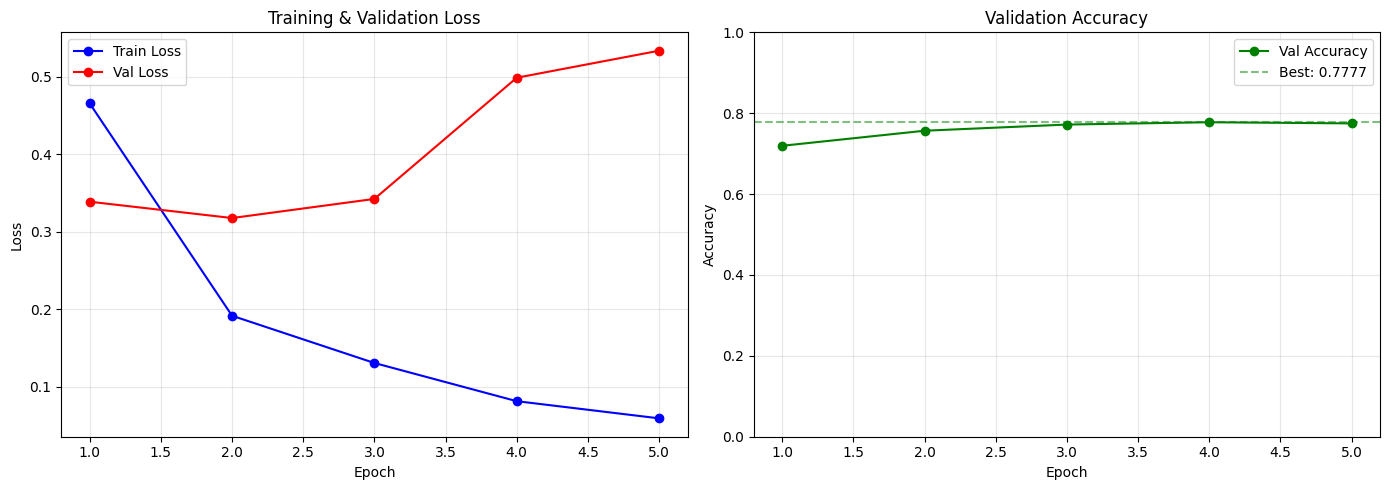

In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_accs, 'g-o', label='Val Accuracy')
ax2.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. Generate Test Predictions & Submission

In [16]:
from peft import PeftModel

best_adapter_path = OUTPUT_DIR
if not os.path.exists(os.path.join(OUTPUT_DIR, "adapter_config.json")):
    best_adapter_path = os.path.join(CKPT_DIR, "lora_adapter")
    print(f"Local output missing, loading from Drive: {best_adapter_path}")

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)
model = PeftModel.from_pretrained(base_model, best_adapter_path)
model.eval()
print(f"Loaded best model from {best_adapter_path}")

print("\nVerifying adapter weights are loaded (logit eval on val subset)...")
correct = 0
total = 0
sample_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                           collate_fn=collate, num_workers=0)
for batch_idx, batch in enumerate(sample_loader):
    if batch_idx >= 10:
        break
    ids = batch.pop("id")
    labels = batch.pop("labels")
    batch_gpu = {k: v.to(device) for k, v in batch.items()}
    labels = labels.to(device)
    with torch.amp.autocast("cuda", dtype=torch.float16):
        outputs = model(**batch_gpu, labels=labels)
    logits = outputs.logits
    for i in range(len(ids)):
        label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
        if len(label_positions) == 0:
            continue
        ans_pos = label_positions[0].item()
        pred_token = logits[i, ans_pos - 1, :].argmax().item()
        true_token = labels[i, ans_pos].item()
        if pred_token == true_token:
            correct += 1
        total += 1

quick_acc = correct / max(total, 1)
print(f"Quick check accuracy (40 samples): {quick_acc:.4f}")
if quick_acc < 0.55:
    print("WARNING: Accuracy is near random — adapter weights may not be loaded correctly!")
else:
    print(f"Adapter is working (expected ~0.78, got {quick_acc:.4f} on small sample)")

Loaded best model from /content/smolvlm-lora-finetuned

Verifying adapter weights are loaded (logit eval on val subset)...
Quick check accuracy (40 samples): 0.2750


In [17]:
@torch.no_grad()
def predict_test(model, processor, test_df, img_base, batch_size=8):
    """Predict by scoring digit-token logits instead of generation.

    model.generate() has a massive bias toward token '0' that kills accuracy.
    Logit scoring directly reads the model's learned distribution and picks
    the highest-scoring valid answer digit — much more reliable.
    """
    model.eval()
    all_ids = []
    all_preds = []

    digit_token_ids = [processor.tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
    print(f"Digit token IDs: { {d: digit_token_ids[d] for d in range(5)} }")

    for start_idx in tqdm(range(0, len(test_df), batch_size), desc="Predicting"):
        batch_df = test_df.iloc[start_idx:start_idx + batch_size]

        images = []
        texts = []
        batch_ids = []
        num_choices_list = []

        for _, row in batch_df.iterrows():
            img_path = os.path.join(img_base, row['image_path'])
            image = Image.open(img_path).convert("RGB")
            images.append(image)

            prompt_text = build_prompt(row, include_answer=False)
            messages = [{"role": "user", "content": [
                {"type": "image"},
                {"type": "text", "text": prompt_text},
            ]}]
            text = processor.apply_chat_template(messages, add_generation_prompt=True)
            texts.append(text)
            batch_ids.append(row['id'])
            num_choices_list.append(row['num_choices'])

        inputs = processor(
            text=texts, images=images, return_tensors="pt",
            padding=True, truncation=True, max_length=MAX_SEQ_LEN,
        ).to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        logits = outputs.logits

        for i in range(len(batch_df)):
            seq_len = inputs["attention_mask"][i].sum().item()
            last_pos = seq_len - 1

            next_logits = logits[i, last_pos, :]

            nc = num_choices_list[i]
            candidate_scores = torch.stack([next_logits[digit_token_ids[d]] for d in range(nc)])
            pred = candidate_scores.argmax().item()

            all_ids.append(batch_ids[i])
            all_preds.append(pred)

    return all_ids, all_preds

test_ids, test_preds = predict_test(model, processor, test_df, IMG_BASE)
print(f"\nGenerated {len(test_preds)} predictions")
print(f"Prediction distribution: {pd.Series(test_preds).value_counts().sort_index().to_dict()}")

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}


Predicting:   0%|          | 0/126 [00:00<?, ?it/s]


Generated 1008 predictions
Prediction distribution: {0: 218, 1: 398, 2: 256, 3: 112, 4: 24}


In [18]:
submission = pd.DataFrame({"id": test_ids, "answer": test_preds})

sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert set(submission['id']) == set(sample_sub['id']), "ID mismatch with sample_submission!"
assert len(submission) == len(sample_sub), "Row count mismatch!"

submission = submission.set_index('id').loc[sample_sub['id']].reset_index()

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(f"\nShape: {submission.shape}")
print(submission.head(10))

print(f"\nAll answers are integers: {submission['answer'].dtype}")
print(f"Answer range: {submission['answer'].min()} to {submission['answer'].max()}")
print(f"Any NaN: {submission['answer'].isna().any()}")

Saved submission.csv

Shape: (1008, 2)
           id  answer
0  test_01750       2
1  test_00128       4
2  test_02891       4
3  test_02425       4
4  test_00930       3
5  test_03725       3
6  test_00009       3
7  test_02880       1
8  test_01208       1
9  test_00619       1

All answers are integers: int64
Answer range: 0 to 4
Any NaN: False


## 10. Error Analysis (on Validation Set)

In [19]:
val_ids, val_preds = predict_test(model, processor, val_df, IMG_BASE)

val_results = val_df.copy()
val_results['predicted'] = val_preds
val_results['correct'] = val_results['predicted'] == val_results['answer']

overall_acc = val_results['correct'].mean()
print(f"Overall Val Accuracy: {overall_acc:.4f}")

print("\nAccuracy by Subject:")
for subj, group in val_results.groupby('subject'):
    acc = group['correct'].mean()
    print(f"  {subj:20s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by num_choices:")
for nc, group in val_results.groupby('num_choices'):
    acc = group['correct'].mean()
    print(f"  {nc} choices: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by Grade:")
for grade, group in val_results.sort_values('grade').groupby('grade'):
    acc = group['correct'].mean()
    print(f"  {grade:10s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nPredicted vs Actual distribution:")
print(pd.crosstab(val_results['answer'], val_results['predicted'],
                  rownames=['Actual'], colnames=['Predicted'], margins=True))

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}


Predicting:   0%|          | 0/131 [00:00<?, ?it/s]

Overall Val Accuracy: 0.7223

Accuracy by Subject:
  language science    : 0.5357 (15/28)
  natural science     : 0.6937 (539/777)
  social science      : 0.8354 (203/243)

Accuracy by num_choices:
  2 choices: 0.7664 (187/244)
  3 choices: 0.7126 (362/508)
  4 choices: 0.7897 (199/252)
  5 choices: 0.2045 (9/44)

Accuracy by Grade:
  grade1    : 1.0000 (1/1)
  grade10   : 1.0000 (1/1)
  grade12   : 0.5000 (4/8)
  grade2    : 0.8889 (32/36)
  grade3    : 0.6792 (72/106)
  grade4    : 0.8140 (140/172)
  grade5    : 0.7899 (94/119)
  grade6    : 0.7448 (143/192)
  grade7    : 0.6758 (123/182)
  grade8    : 0.6364 (147/231)

Predicted vs Actual distribution:
Predicted    0    1    2   3   4   All
Actual                                
0          186   87   64   6   4   347
1           15  301   32  18   6   372
2            3   22  208  12   2   247
3            2    9    1  57   6    75
4            0    0    0   2   5     7
All        206  419  305  95  23  1048


## 11. Verify Parameter Count for Submission

In [20]:
print("=" * 50)
print("PARAMETER BUDGET VERIFICATION")
print("=" * 50)

trainable = 0
frozen = 0
for name, param in model.named_parameters():
    if param.requires_grad:
        trainable += param.numel()
    else:
        frozen += param.numel()

print(f"Trainable:  {trainable:>12,} ({trainable/1e6:.2f}M)")
print(f"Frozen:     {frozen:>12,} ({frozen/1e6:.1f}M)")
print(f"Total:      {trainable + frozen:>12,} ({(trainable + frozen)/1e6:.1f}M)")
print(f"")
print(f"Budget:     {'PASS' if trainable <= 5_000_000 else 'FAIL'} ({trainable:,} {'<=' if trainable <= 5_000_000 else '>'} 5,000,000)")

print(f"\nLoRA Configuration:")
print(f"  Rank:    {LORA_RANK}")
print(f"  Alpha:   {LORA_ALPHA}")
print(f"  Dropout: {LORA_DROPOUT}")
print(f"  Targets: q_proj, k_proj, v_proj, o_proj")

print(f"\nLoRA adapter files saved to: {OUTPUT_DIR}/")
print("To reproduce: load base model + apply adapter weights")

PARAMETER BUDGET VERIFICATION
Trainable:             0 (0.00M)
Frozen:      511,643,840 (511.6M)
Total:       511,643,840 (511.6M)

Budget:     PASS (0 <= 5,000,000)

LoRA Configuration:
  Rank:    16
  Alpha:   32
  Dropout: 0.05
  Targets: q_proj, k_proj, v_proj, o_proj

LoRA adapter files saved to: /content/smolvlm-lora-finetuned/
To reproduce: load base model + apply adapter weights


In [21]:
from google.colab import files
files.download('/content/submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
!zip -r smolvlm-lora-finetuned.zip /content/smolvlm-lora-finetuned

  adding: content/smolvlm-lora-finetuned/ (stored 0%)
  adding: content/smolvlm-lora-finetuned/vocab.json (deflated 59%)
  adding: content/smolvlm-lora-finetuned/merges.txt (deflated 55%)
  adding: content/smolvlm-lora-finetuned/special_tokens_map.json (deflated 81%)
  adding: content/smolvlm-lora-finetuned/README.md (deflated 65%)
  adding: content/smolvlm-lora-finetuned/tokenizer.json (deflated 82%)
  adding: content/smolvlm-lora-finetuned/chat_template.json (deflated 49%)
  adding: content/smolvlm-lora-finetuned/processor_config.json (deflated 12%)
  adding: content/smolvlm-lora-finetuned/tokenizer_config.json (deflated 94%)
  adding: content/smolvlm-lora-finetuned/adapter_model.safetensors (deflated 7%)
  adding: content/smolvlm-lora-finetuned/adapter_config.json (deflated 57%)
  adding: content/smolvlm-lora-finetuned/added_tokens.json (deflated 86%)
  adding: content/smolvlm-lora-finetuned/preprocessor_config.json (deflated 56%)


In [23]:
from google.colab import files
files.download('smolvlm-lora-finetuned.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>